# Model Building – Month 2, Lesson 1 Homework:
# Implement all learned algorithms using functions and analyze the results with Matplotlib, Seaborn, and Plotly Express.

In [1]:
import pandas as pd

In [80]:
df = pd.read_csv('bank_transactions_data_2_augmented_clean_2.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  str    
 1   AccountID            50000 non-null  str    
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  str    
 4   TransactionType      50000 non-null  str    
 5   Location             50000 non-null  str    
 6   DeviceID             50000 non-null  str    
 7   IP Address           50000 non-null  str    
 8   MerchantID           50000 non-null  str    
 9   Channel              50000 non-null  str    
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  str    
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), str(10)
memory usage: 

In [4]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [5]:
df.isnull().sum()

TransactionID          0
AccountID              0
TransactionAmount      0
TransactionDate        0
TransactionType        0
Location               0
DeviceID               0
IP Address             0
MerchantID             0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
LoginAttempts          0
AccountBalance         0
dtype: int64

In [6]:
df.nunique()

TransactionID          50000
AccountID                495
TransactionAmount      34837
TransactionDate         6373
TransactionType            2
Location                  43
DeviceID                 681
IP Address               592
MerchantID               100
Channel                    3
CustomerAge               63
CustomerOccupation         4
TransactionDuration      288
LoginAttempts              5
AccountBalance          2510
dtype: int64

In [7]:
# Drop keraksiz ustunlarni 
df.drop(['TransactionID', 'DeviceID', 'MerchantID', 'IP Address'], axis=1, inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AccountID            50000 non-null  str    
 1   TransactionAmount    50000 non-null  float64
 2   TransactionDate      50000 non-null  str    
 3   TransactionType      50000 non-null  str    
 4   Location             50000 non-null  str    
 5   Channel              50000 non-null  str    
 6   CustomerAge          50000 non-null  int64  
 7   CustomerOccupation   50000 non-null  str    
 8   TransactionDuration  50000 non-null  int64  
 9   LoginAttempts        50000 non-null  int64  
 10  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), str(6)
memory usage: 4.2 MB


In [9]:
# Encoding 
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

def encodla(df):
    encoder = LabelEncoder()
    for col in df.columns:
        if df[col].dtype != 'object':
            df[col] = encoder.fit_transform(df[col])
    return df
df = encodla(df)
        

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   AccountID            50000 non-null  int64
 1   TransactionAmount    50000 non-null  int64
 2   TransactionDate      50000 non-null  int64
 3   TransactionType      50000 non-null  int64
 4   Location             50000 non-null  int64
 5   Channel              50000 non-null  int64
 6   CustomerAge          50000 non-null  int64
 7   CustomerOccupation   50000 non-null  int64
 8   TransactionDuration  50000 non-null  int64
 9   LoginAttempts        50000 non-null  int64
 10  AccountBalance       50000 non-null  int64
dtypes: int64(11)
memory usage: 4.2 MB


In [11]:
df.head()

,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,126,1024,3253,1,36,0,52,0,71,0,1306
1,450,22237,4569,1,15,0,50,0,131,0,2439
2,18,9308,4796,1,23,2,1,3,46,0,452
3,68,12786,4162,1,33,2,8,3,15,0,2024
4,406,972,686,0,1,2,8,3,188,0,1820


# train_test_split process 

In [12]:
# Here we can see the amount of something better not to do scaling
from sklearn.model_selection import train_test_split

x = df.drop('TransactionType', axis=1)
y = df['TransactionType']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state=42
)



In [13]:
x_train.shape

(35000, 10)

In [14]:
x_test.shape

(15000, 10)

In [15]:
y_train.shape

(35000,)

In [16]:
y_test.shape

(15000,)

In [17]:
# Model Selection
from sklearn.linear_model import LogisticRegression, LinearRegression

In [18]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
y_pred = lr.predict(x_test)


In [20]:
y_pred[0:5]

array([1, 1, 1, 1, 1])

In [21]:
# Evaluation 
from sklearn.metrics import classification_report

In [22]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3331
           1       0.78      1.00      0.88     11669

    accuracy                           0.78     15000
   macro avg       0.39      0.50      0.44     15000
weighted avg       0.61      0.78      0.68     15000



/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

# Linear Regression 

In [23]:
lr_reg = LinearRegression()



In [24]:
x = df.drop('TransactionAmount', axis=1)
y = df['TransactionAmount'].astype(int)

In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [26]:
lr_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
y_pred = lr_reg.predict(x_test)

In [28]:
y_pred[0:10]

array([15532.80211725, 15026.01777931, 15269.211941  , 15657.72489755,
       15012.98516959, 15509.95145524, 15321.87200763, 14627.88968382,
       15368.27072976, 15406.40285046])

In [29]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [30]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)



0.00117463918012084
8694.239389547634
100741917.24696131


# Decison Tree Classifier

In [31]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [32]:
dt_class = DecisionTreeClassifier()
dt_reg = DecisionTreeRegressor()

In [33]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop('TransactionType', axis=1)
y = df['TransactionType']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [34]:
dt_class.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [35]:
y_pred = dt_class.predict(x_test)

In [36]:
y_pred[0:10]

array([0, 0, 1, 1, 1, 1, 0, 1, 1, 1])

In [37]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2242
           1       1.00      1.00      1.00      7758

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# Decision Tree Regressor 

In [38]:
x = df.drop('TransactionAmount', axis=1)
y = df['TransactionAmount']

In [39]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [40]:
dt_reg.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [41]:
y_pred = dt_reg.predict(x_test)

In [42]:
y_pred[0:10]

array([ 5437., 18746., 26405., 10927.,  5487., 15703.,  6923.,   327.,
       19620., 34695.])

In [43]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.9951098583777552
498.164
493221.60005


# Random Forest Classifier 

In [44]:
from sklearn.ensemble import RandomForestClassifier 

rf_class = RandomForestClassifier()

In [45]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop('TransactionType', axis=1)
y = df['TransactionType']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [46]:
rf_class.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
y_pred = rf_class.predict(x_test)

In [48]:
y_pred[0:10]

array([0, 0, 1, 1, 1, 1, 0, 1, 1, 1])

In [49]:
# Evaluation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2242
           1       1.00      1.00      1.00      7758

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



# Random Forest Regressor 

In [50]:
from sklearn.ensemble import RandomForestRegressor 

rf_reg = RandomForestRegressor()

In [51]:
x = df.drop('TransactionAmount', axis=1)
y = df['TransactionAmount']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_reg.fit(x_train, y_train)

y_pred = rf_reg.predict(x_test)


In [52]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)


0.9965148182363437
421.02857051349207
351516.79822855355


# Support Vector Machine Classifier 

In [53]:
from sklearn.svm import SVC, SVR

In [54]:
df.head()

,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,126,1024,3253,1,36,0,52,0,71,0,1306
1,450,22237,4569,1,15,0,50,0,131,0,2439
2,18,9308,4796,1,23,2,1,3,46,0,452
3,68,12786,4162,1,33,2,8,3,15,0,2024
4,406,972,686,0,1,2,8,3,188,0,1820


In [55]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop('TransactionType', axis=1)
y = df['TransactionType']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [56]:
# Bunda Scaling qilish juda muhim ekan sababi u ham huddi linearga o'xshab hyperline chizig'i bilan ajratiladi klaslar. Iloji boricha MinMaxScaler bilan qilgan maqul 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=['int64']).columns.drop('TransactionType')
df[num_cols] = scaler.fit_transform(df[num_cols])

In [57]:
svc = SVC(kernel='linear', C=1.0, max_iter=2000)


In [58]:
svc.fit(x_train, y_train)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [59]:
y_pred = svc.predict(x_test)

In [60]:
y_pred[0:10]

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 1])

In [61]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.22      0.58      0.32      2242
           1       0.76      0.39      0.52      7758

    accuracy                           0.43     10000
   macro avg       0.49      0.49      0.42     10000
weighted avg       0.64      0.43      0.47     10000



# Support Vector Regressor

In [62]:
from sklearn.svm import SVR

In [63]:
svr = SVR(kernel='rbf', C=2.0)

In [64]:
x = df.drop('TransactionAmount', axis=1)
y = df['TransactionAmount']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_reg.fit(x_train, y_train)

y_pred = rf_reg.predict(x_test)

In [65]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.9965223243183589
0.012074735078996002
0.0002890368167984691


# Tabulate orqali javdval tuzamiz va algoritmlarimizni taqqoslaymiz. 

In [66]:
import sys
!{sys.executable} -m pip install tabulate


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [67]:
from tabulate import tabulate

In [68]:
results_class = [
    ['Logistic Regression', 0.78,0.78,1.00,0.88],
    ['Decison Tree Classifier', 1.00,1.00,1.00,1.00],
    ['Random Forest Classifier', 1.00, 1.00, 1.00,1.00],
    ['Support Vector Classifier', 0.43, 0.76, 0.39,0.52]
]

results_reg = [
    ['Linear Regressor', 0.001, 8694.23, 100741917.24],
    ['Decison Tree Regressor', 0.99, 497.99, 493250.44],
    ['Random Forest Regressor', 0.99, 419, 349241],
    ['Support Vector Regressor', 0.75, 0.10, 0.01]
]

headers_class = ['Algorithms', 'Accuracy', 'Precision', 'Recall', 'f1_score']
table_class = tabulate(results_class, headers=headers_class, tablefmt='grid', floatfmt='.2f')
print(table_class)

print('---------------------------------------------------------------------------------')
print('##################################################################################')
print('---------------------------------------------------------------------------------')

headers_reg = ['Algorithms', 'r2_score', 'mean_absolute_error', 'mean_squared_error']
table_reg = tabulate(results_reg, headers=headers_reg, tablefmt='grid', floatfmt='.2f')
print(table_reg)




+---------------------------+------------+-------------+----------+------------+
| Algorithms                |   Accuracy |   Precision |   Recall |   f1_score |
+===========================+============+=============+==========+============+
| Logistic Regression       |       0.78 |        0.78 |     1.00 |       0.88 |
+---------------------------+------------+-------------+----------+------------+
| Decison Tree Classifier   |       1.00 |        1.00 |     1.00 |       1.00 |
+---------------------------+------------+-------------+----------+------------+
| Random Forest Classifier  |       1.00 |        1.00 |     1.00 |       1.00 |
+---------------------------+------------+-------------+----------+------------+
| Support Vector Classifier |       0.43 |        0.76 |     0.39 |       0.52 |
+---------------------------+------------+-------------+----------+------------+
---------------------------------------------------------------------------------
###########################

In [69]:
# Eng yaxshi Classifier va eng yaxshi Regressor Algoritmini topish 

best_model_class = results_class[0]

for model in results_class:
    if model[1] > best_model_class[1]:
        best_model_class = model
print(f"Eng yaxshi model Classifier uchun: ", best_model_class[0])
print(f"Eng yaxshi model metriging qiymati: ", best_model_class[1])




Eng yaxshi model Classifier uchun:  Decison Tree Classifier
Eng yaxshi model metriging qiymati:  1.0


In [70]:
best_model_reg = results_reg[0]

for model_reg in results_reg:
    if model_reg[3] < best_model_reg[3]:
        best_model_reg = model_reg
print(f"Eng yaxshi model Regressor uchun: ", best_model_reg[0])
print(f"Eng yaxshi MSE qiymati: ", best_model_reg[3])

Eng yaxshi model Regressor uchun:  Support Vector Regressor
Eng yaxshi MSE qiymati:  0.01


# Pyplot, seaborn and plotly express qo'llash va analiz qilish 

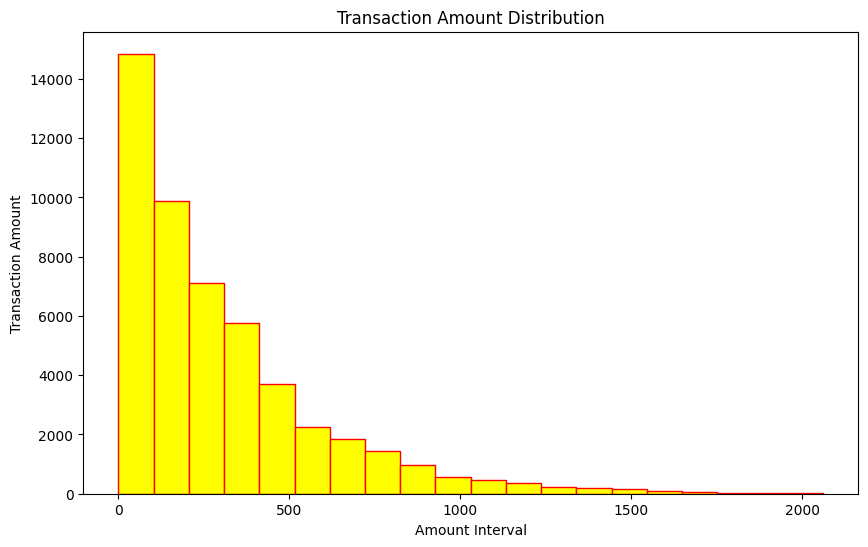

In [84]:
# Matplotlibni import qilib olamiz 
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))  # Figure measurement 
plt.hist(df['TransactionAmount'], bins=20, color='yellow', edgecolor='red')
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount Interval')
plt.ylabel('Transaction Amount')
plt.show()


In [72]:
"""
Bu yerda Transaction Amount Distribution holatida bizda x-o'qida 
bu summa intervali, y-o'qida esa bizda nechi marta transaction bo'lganligidir.
Bu yerda 0-100 tagacha atrofida transactionlar soni ancha yuqori bo'lganligi ko'rinadi
"""

"\nBu yerda Transaction Amount Distribution holatida bizda x-o'qida \nbu summa intervali, y-o'qida esa bizda nechi marta transaction bo'lganligidir.\nBu yerda 0-5000 gacha transactionlar soni ancha yuqori bo'lganligi ko'rinadi\n\n\n"

# Saborn 

In [85]:
import seaborn as sns 

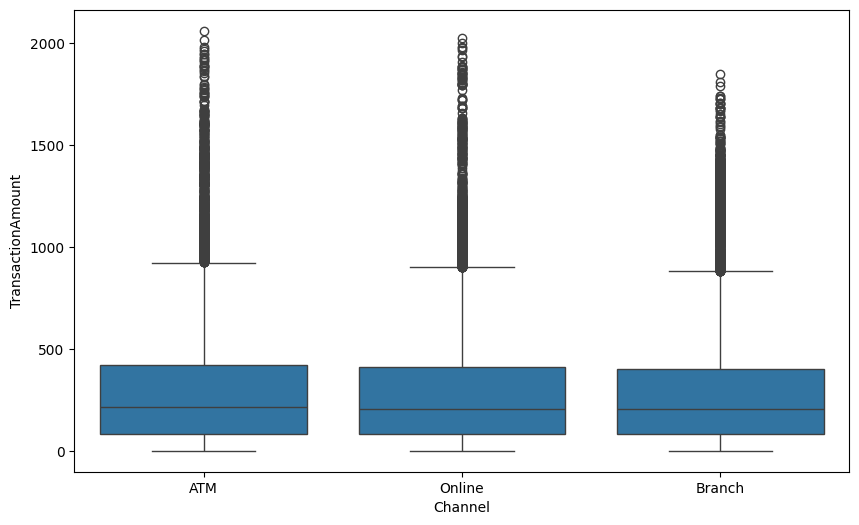

In [86]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Channel', y='TransactionAmount', data=df)
plt.show()

In [75]:
"""
Bu yerda esa biz seaborn bilan Channel va Transaction Amount solishtirdik sababi 
qaysi usullar bilan ular transaction qilishgan uchala holatdan ATMda ko'proq 
transaction qilingani ko'rinib turibdi.
"""

"\nBu yerda esa biz seaborn bilan Channel va Transaaction Amount solishtirdik sababi \nsababi qaysi usullar bilan ular transaction qilishgan uchala holatdan ATMda ko'proq \ntransaction qilingani ko'rinib turibdi.\n\n\n"

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AccountID            50000 non-null  float64
 1   TransactionAmount    50000 non-null  float64
 2   TransactionDate      50000 non-null  float64
 3   TransactionType      50000 non-null  int64  
 4   Location             50000 non-null  float64
 5   Channel              50000 non-null  float64
 6   CustomerAge          50000 non-null  float64
 7   CustomerOccupation   50000 non-null  float64
 8   TransactionDuration  50000 non-null  float64
 9   LoginAttempts        50000 non-null  float64
 10  AccountBalance       50000 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 4.2 MB


# Plotly Express


In [87]:
import plotly.express as px

In [89]:
fig = px.scatter(df, x='AccountBalance', y='TransactionAmount', color='AccountBalance', size='AccountBalance', hover_data=['TransactionAmount', 'AccountBalance'], title='Qaysi holatda va qancha miqdorda tranzaksiya bolganinini korsatuvchi graph')
fig.show()

In [ ]:
"""
Bu yerda esa biz plotly.express bilan Acount Balance va Transaction Amount ni ko'rdik
va etibroli jihati 0-2k gacha qiymatda balansi borlari grafikda ancha zich holatda
transactionlar qilinganligini ko'rdik
"""